# Классификация: Логистическая регрессия и SVM

###  Загрузка данных и импорт библиотек

In [1]:
# Импортируем библиотеки

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Машинное обучение

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    TargetEncoder
)

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier

In [2]:
# Фиксируем random_state для воспроизводимости результатов
RANDOM_STATE = 42

In [3]:
# Загружаем датасет
df = pd.read_csv('adult.csv')


**Информация о признаках**


1. age: continuous.
2. workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
3. fnlwgt: continuous.
4. education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
5. education-num: continuous.
6. marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
7. occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
8. relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
9. race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
10. sex: Female, Male.
11. capital-gain: continuous.
12. capital-loss: continuous.
13. hours-per-week: continuous.
14. native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.
15. class: >50K, <=50K

Посмотрим первые и последние строки

In [4]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
df.tail()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [6]:
# Выводим подробную информацию
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
# Создадим копию датасета до преобразования для возможности оценить сделанные изменения
tmp_df = df.copy()
len(tmp_df)

48842

###  Предварительный анализ данных

In [8]:
# Проверяем наличие пропусков
df.isna().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

Пропусков нет, хотя в описании датасета указано, что пропуски составляют 7%. Возможно, имеются значения-заглушки, обозначающие отсутствие данных.

In [9]:
# Проверяем явные дубликаты
df.duplicated().sum()

52

Есть 52 явных дубликата, удалим их.

In [10]:
# удаляем явные дубликаты
df = df.drop_duplicates()

In [11]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [12]:
df.dtypes

age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

In [13]:
# Посмотрим на числовые переменные
num_columns = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

df[num_columns].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,48790.0,38.652798,13.708493,17.0,28.0,37.0,48.00,90.0
fnlwgt,48790.0,189668.999365,105617.231232,12285.0,117555.0,178138.5,237606.25,1490400.0
educational-num,48790.0,10.078807,2.570046,1.0,9.0,10.0,12.00,16.0
capital-gain,48790.0,1080.217688,7455.905921,0.0,0.0,0.0,0.00,99999.0
capital-loss,48790.0,87.595573,403.209129,0.0,0.0,0.0,0.00,4356.0
hours-per-week,48790.0,40.425886,12.392729,1.0,40.0,40.0,45.00,99.0


Числовые признаки для анализа: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


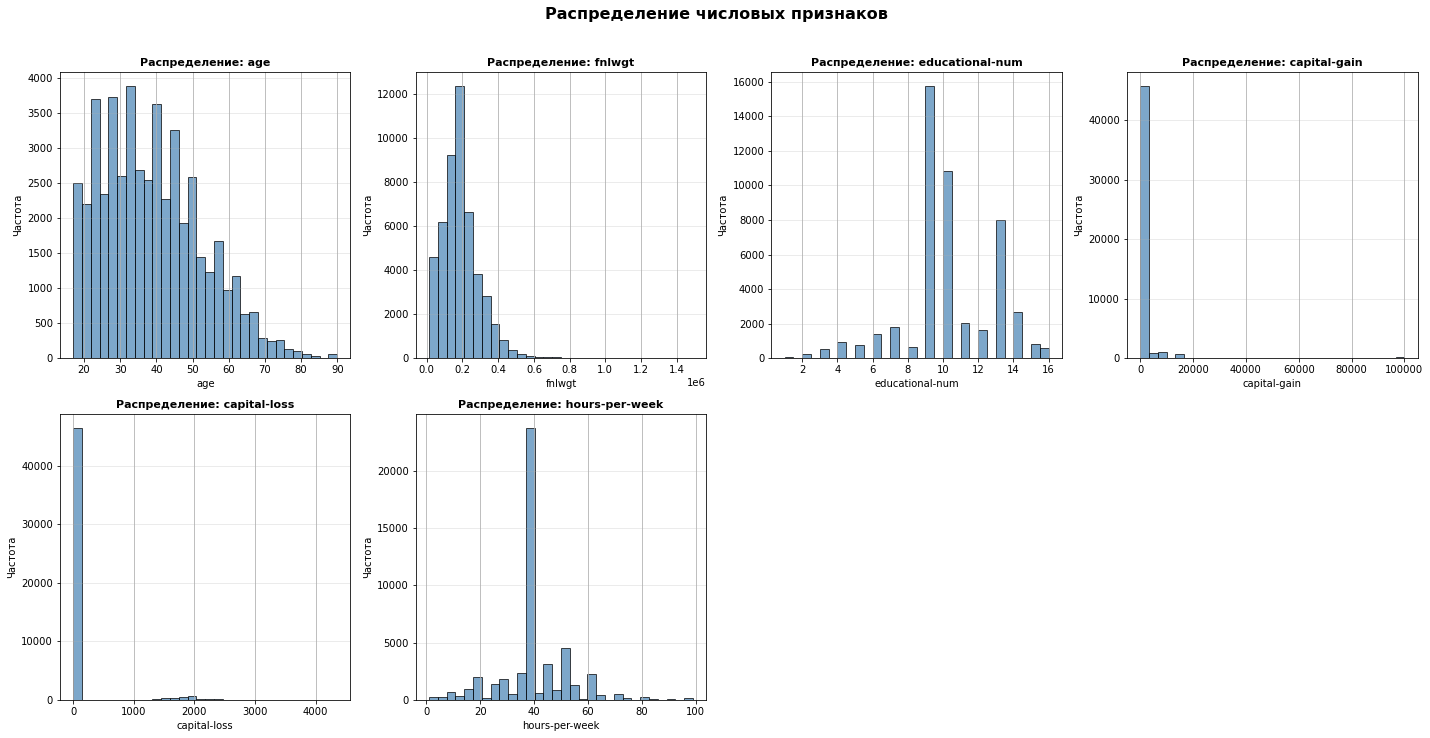

In [14]:
# Анализ выбросов в числовых признаках

numerical_for_hist = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовые признаки для анализа: {numerical_for_hist}")

# Гистограммы распределений
n_cols = len(numerical_for_hist)
n_rows = (n_cols + 3) // 4

plt.figure(figsize=(20, n_rows * 5))

for i, col in enumerate(numerical_for_hist, 1):
    plt.subplot(n_rows, 4, i)
    df[col].dropna().hist(bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    title, xlabel, ylabel = col, col, 'Частота'
    plt.title(f'Распределение: {title}', fontsize=11, fontweight='bold')
    plt.xlabel(xlabel, fontsize=10)
    plt.ylabel(ylabel, fontsize=10)
    plt.grid(axis='y', alpha=0.3)

plt.suptitle('Распределение числовых признаков', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Распределение числовых признаков не является нормальным. Максимальные значения capital-gain 99999 и hours-per-week 99 выглядят явно искусственными значениями и являются выбросами. Вероятно, это значения-заглушки и по сути это пропуски в данных. По условию задания удалим эти строки. Можно было бы заменить медианой.

In [15]:
print(f"Значения capital-gain = 99999 содержатся в {df[df['capital-gain'] == 99999].shape[0]} строках")
print(f"Это составляет {len(df[df['capital-gain'] == 99999]) / len(df) * 100:.2f}%")
print(f"Значения hours-per-week = 99 содержатся в {df[df['hours-per-week'] == 99].shape[0]} строках")
print(f"Это составляет {len(df[df['hours-per-week'] == 99]) / len(df) * 100:.2f}%")

Значения capital-gain = 99999 содержатся в 244 строках
Это составляет 0.50%
Значения hours-per-week = 99 содержатся в 137 строках
Это составляет 0.28%


In [16]:
# Удаляем строки с выбросами
df = df[
    (df['capital-gain'] != 99999) & 
    (df['hours-per-week'] != 99)
]

In [17]:
# Статистика категориальных переменных
df.describe(include=['object', 'category'])

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,48410,48410,48410,48410,48410,48410,48410,48410,48410
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States,<=50K
freq,33671,15696,22086,6076,19445,41378,32301,43448,37013


In [18]:
# Категориальные признаки
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные признаки ({len(categorical_cols)}):")
print(categorical_cols)

# Анализ уникальных значений
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Уникальных значений: {df[col].nunique()}")
    print(f"  Топ-5 значений:")
    print(df[col].value_counts().head())

Категориальные признаки (9):
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']

workclass:
  Уникальных значений: 9
  Топ-5 значений:
Private             33671
Self-emp-not-inc     3785
Local-gov            3122
?                    2779
State-gov            1974
Name: workclass, dtype: int64

education:
  Уникальных значений: 16
  Топ-5 значений:
HS-grad         15696
Some-college    10823
Bachelors        7938
Masters          2618
Assoc-voc        2051
Name: education, dtype: int64

marital-status:
  Уникальных значений: 7
  Топ-5 значений:
Married-civ-spouse    22086
Never-married         16039
Divorced               6588
Separated              1524
Widowed                1513
Name: marital-status, dtype: int64

occupation:
  Уникальных значений: 15
  Топ-5 значений:
Craft-repair       6076
Prof-specialty     6040
Exec-managerial    5997
Adm-clerical       5596
Sales              5461
Name: occupation, dtype: in

In [19]:
for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print('-'* 10)

workclass
['Private' 'Local-gov' '?' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
----------
education
['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool']
----------
marital-status
['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']
----------
occupation
['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' '?'
 'Other-service' 'Prof-specialty' 'Craft-repair' 'Adm-clerical'
 'Exec-managerial' 'Tech-support' 'Sales' 'Priv-house-serv'
 'Transport-moving' 'Handlers-cleaners' 'Armed-Forces']
----------
relationship
['Own-child' 'Husband' 'Not-in-family' 'Unmarried' 'Wife' 'Other-relative']
----------
race
['Black' 'White' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']
----------
gender
['Male' 'Female']
----------
native-country
['United-States' '?' 'Peru' 

В колонках workclass и native-country есть значения '?', по сути это пропуски. По условию задачи пропуски удаляем. Посмотрим, сколько таких значений

In [20]:
columns = ['workclass', 'native-country']
for col in columns:
    print(f'Абсолютные значения для {col}:')
    print(df[col].value_counts())
    print()
    print(f'Доли для {col}:')
    print(df[col].value_counts(normalize=True))
    print('=' * 40)

Абсолютные значения для workclass:
Private             33671
Self-emp-not-inc     3785
Local-gov            3122
?                    2779
State-gov            1974
Self-emp-inc         1620
Federal-gov          1428
Without-pay            21
Never-worked           10
Name: workclass, dtype: int64

Доли для workclass:
Private             0.695538
Self-emp-not-inc    0.078186
Local-gov           0.064491
?                   0.057405
State-gov           0.040777
Self-emp-inc        0.033464
Federal-gov         0.029498
Without-pay         0.000434
Never-worked        0.000207
Name: workclass, dtype: float64
Абсолютные значения для native-country:
United-States                 43448
Mexico                          940
?                               843
Philippines                     290
Germany                         206
Puerto-Rico                     184
Canada                          181
El-Salvador                     155
India                           147
Cuba                   

Для workclass 5.7% составляют '?', для native-country такие значения содержат 1.7% строк. Можно было бы заменить модой:
- для workclass сгруппировав по education
- для native-country взяв самое частое значение для каждой расы

In [21]:
# Удаляем пропуски

df = df[
    (df['workclass'] != '?') & 
    (df['native-country'] != '?')
]

Больше всего уникальных значений имеет признак native-country. Посмотрим на распределение

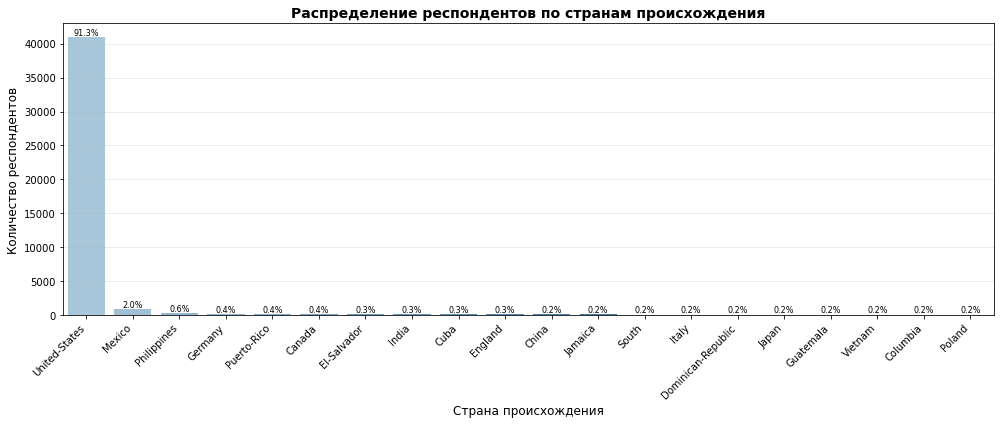

In [22]:
# Анализ native-country
country_stats = df['native-country'].value_counts().reset_index()
country_stats.columns = ['native-country', 'count']
country_stats['percent'] = (country_stats['count'] / len(df)) * 100
country_stats['cumsum_percent'] = country_stats['percent'].cumsum()

# Визуализация
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=country_stats.head(20), 
    x='native-country', 
    y='count',
    palette='Blues_d'
)

for i, row in country_stats.head(20).iterrows():
    ax.text(i, row['count'] + 10, f"{row['percent']:.1f}%", 
            ha='center', va='bottom', fontsize=8)

plt.title(
    'Распределение респондентов по странам происхождения', 
    fontsize=14, fontweight='bold'
)
plt.xlabel('Страна происхождения', fontsize=12)
plt.ylabel('Количество респондентов', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Доля США составляет 89.8% от всей выборки

In [23]:
# Проверим сколько удалено строк датасета
a, b = len(tmp_df), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))


 Было строк в исходном датасете 48842 
 Осталось строк в датасете после обработки 44834 
 Удалено строк в датасете после обработки 4008 
 Процент потерь 8.21


Признак fnlwgt, насколько я понимаю, это весовой коэффициент, который используется в статистике для того, чтобы сделать выборку репрезентативной. В таком случае его необходимо удалить перед обучением модели, полезной информации о конкретном человеке он не несет.

In [24]:
# Удаляем неважный признак fnlwgt
df = df.drop('fnlwgt', axis=1)


Категориальные переменные необходимо кодировать. Для признаков, имеющих < 10 уникальных значений, будем использовать OneHotEncoder, для остальных TargetEncoder.

**Анализ целевой переменной**

In [25]:
# Анализ целевой переменной
print("Распределение целевой переменной income:")
income_counts = df['income'].value_counts()
print(income_counts)
print("\nВ процентном соотношении:")
print(df['income'].value_counts(normalize=True) * 100)

Распределение целевой переменной income:
<=50K    33900
>50K     10934
Name: income, dtype: int64

В процентном соотношении:
<=50K    75.612259
>50K     24.387741
Name: income, dtype: float64


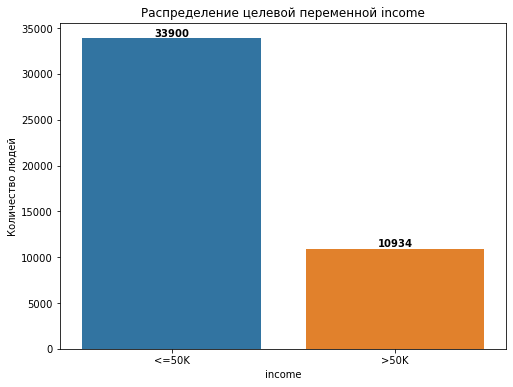

In [26]:
# Визуализация распределения целевой переменной
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='income', data=df)

# Добавляем подписи
for i, v in enumerate(income_counts.values):
    ax.text(i, v + 0.2, f'{v}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
plt.title('Распределение целевой переменной income')
plt.xlabel('income')
plt.ylabel('Количество людей')
plt.show()

In [27]:
imbalance_ratio = income_counts[0] / income_counts[1]
print(f"Коэффициент дисбаланса: {imbalance_ratio:.1f}:1")

Коэффициент дисбаланса: 3.1:1


Есть значительный дисбаланс классов в целевой переменной - необходимо использовать стратификацию при разделении на train и test.


Целевую переменную необходимо преобразовать в числовой формат для дальнейшей работы с моделями

In [28]:
# Преобразование целевой переменной
df['income'] = df['income'].map({'>50K': 1, '<=50K': 0})

### Предобработка данных

In [29]:
# Подготовка признаков и целевой переменной
X = df.drop('income', axis=1)
y = df['income']


In [30]:
# Разделяем на train/test (80/20) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [31]:
# Размеры выборок
print(f"\nРазмеры выборок:")
print(f"Обучающая выборка: {X_train.shape[0]} строк, {X_train.shape[1]} признаков")
print(f"Тестовая выборка: {X_test.shape[0]} строк, {X_test.shape[1]} признаков")


Размеры выборок:
Обучающая выборка: 35867 строк, 13 признаков
Тестовая выборка: 8967 строк, 13 признаков


In [32]:
# Определяем категориальные признаки
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

low_cardinality = ['gender', 'race', 'relationship', 'marital-status', 'workclass']
high_cardinality = ['occupation', 'native-country', 'education']


In [33]:
# Определяем числовые признаки
numeric_cols = df.select_dtypes(include=['int64']).columns.tolist()
numeric_cols.remove('income')

In [34]:
# Создаем препроцессор
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_cardinality),
    ('target', TargetEncoder(), high_cardinality),
    ('numeric', StandardScaler(), numeric_cols)
])

In [35]:
# Проверяем рабоne препроцессора
X_train_processed = preprocessor.fit_transform(X_train, y_train)
print(f'размерность после препроцессора: {X_train_processed.shape}')

размерность после препроцессора: (35867, 36)


###  Построение моделей

In [36]:
# Пайплайн для dummy-модели
pipeline_dummy = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
])


# Пайплайн для логистической регрессии
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced'))
])

# Пайплайн для SVM
pipeline_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=RANDOM_STATE, class_weight='balanced', probability=True))
])

In [ ]:
# Обучаем все модели
pipeline_dummy.fit(X_train, y_train)
pipeline_lr.fit(X_train, y_train)
pipeline_svm.fit(X_train, y_train)

In [ ]:
# Функция для оценки модели
def evaluate(model, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f'{name:10} | Accuracy: {acc:.4f} | ROC-AUC: {roc:.4f}')

In [ ]:
# Смотрим результаты baseline модели, LogReg, SVM с параметрами по умолчанию 
evaluate(pipeline_dummy, 'Dummy')
evaluate(pipeline_lr, 'LogReg')
evaluate(pipeline_svm, 'SVM')

### Выводы по работе

**Преобразования данных**

1. Удалены явные дубликаты (52 строки).
2. Обработаны пропуски: значения `?` в столбцах `workclass` и `native-country` удалены как пропуски.
3. Удалены выбросы-заглушки: строки с `capital-gain = 99999` и `hours-per-week = 99` (менее 1% данных).
4. Удалён признак `fnlwgt`, так как он является весовым коэффициентом и не несёт полезной информации для модели.
5. Целевая переменная преобразована в числовой формат (`<=50K` → `0`, `>50K` → `1`).
6. Категориальные признаки закодированы:
   - с малым числом категорий (`gender`, `race`, `relationship`, `marital-status`, `workclass`) — OneHotEncoding;
   - с большим числом категорий (`occupation`, `native-country`, `education`) — Target Encoding.
7. Числовые признаки масштабированы с помощью `StandardScaler`.

---

**Сравнение точности моделей**

| Модель | Accuracy | ROC-AUC |
| :--- | :--- | :--- |
| **Dummy (baseline)** | 0.756 | 0.500 |
| **Логистическая регрессия** | **0.807** | **0.902** |
| **SVM** | 0.802 | 0.900 |

Логистическая регрессия показала наилучший результат (Accuracy 80.7%, ROC-AUC 0.902). Обе модели значительно превосходят случайное угадывание и демонстрируют хорошую способность разделять классы.

---

Модели справились с поставленной задачей удовлетворительно. Несмотря на небольшое превосходство над baseline по Accuracy (5%), высокий показатель ROC-AUC (>0.9) подтверждает, что модели эффективно разделяют классы. Основное ограничение связано с дисбалансом классов в данных.

Логистическая регрессия и SVM показали сопоставимые результаты, однако логистическая регрессия обучается значительно быстрее. Учитывая незначительную разницу в качестве, для практического использования предпочтительнее логистическая регрессия.

**Рекомендации для улучшения:**

- Использовать подбор гиперпараметров.
- Добавить новые признаки, если это возможно.
